Shape of dataset: (100000, 16)


,id,age,gender,bmi,daily_steps,sleep_hours,water_intake_l,calories_consumed,smoker,alcohol,resting_hr,systolic_bp,diastolic_bp,cholesterol,family_history,disease_risk
0,1,56,Male,20.5,4198,3.9,3.4,1602,0,0,97,161,111,240,0,0
1,2,69,Female,33.3,14359,9.0,4.7,2346,0,1,68,116,65,207,0,0
2,3,46,Male,31.6,1817,6.6,4.2,1643,0,1,90,123,99,296,0,0
3,4,32,Female,38.2,15772,3.6,2.0,2460,0,0,71,165,95,175,0,0
4,5,60,Female,33.6,6037,3.8,4.0,3756,0,1,98,139,61,294,0,0



--- Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 16 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   id                 100000 non-null  int64  
 1   age                100000 non-null  int64  
 2   gender             100000 non-null  object 
 3   bmi                100000 non-null  float64
 4   daily_steps        100000 non-null  int64  
 5   sleep_hours        100000 non-null  float64
 6   water_intake_l     100000 non-null  float64
 7   calories_consumed  100000 non-null  int64  
 8   smoker             100000 non-null  int64  
 9   alcohol            100000 non-null  int64  
 10  resting_hr         100000 non-null  int64  
 11  systolic_bp        100000 non-null  int64  
 12  diastolic_bp       100000 non-null  int64  
 13  cholesterol        100000 non-null  int64  
 14  family_history     100000 non-null  int64  
 15  disease_risk       100000 non-null  in

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,100000.0,NaN,NaN,NaN,50000.5,28867.657797,1.0,25000.75,50000.5,75000.25,100000.0
age,100000.0,NaN,NaN,NaN,48.52599,17.886768,18.0,33.0,48.0,64.0,79.0
gender,100000,2,Male,50132,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bmi,100000.0,NaN,NaN,NaN,29.02479,6.352666,18.0,23.5,29.0,34.5,40.0
daily_steps,100000.0,NaN,NaN,NaN,10479.87029,5483.63236,1000.0,5729.0,10468.0,15229.0,19999.0
sleep_hours,100000.0,NaN,NaN,NaN,6.491784,2.021922,3.0,4.7,6.5,8.2,10.0
water_intake_l,100000.0,NaN,NaN,NaN,2.751496,1.297338,0.5,1.6,2.8,3.9,5.0
calories_consumed,100000.0,NaN,NaN,NaN,2603.3412,807.288563,1200.0,1906.0,2603.0,3299.0,3999.0
smoker,100000.0,NaN,NaN,NaN,0.20094,0.400705,0.0,0.0,0.0,0.0,1.0
alcohol,100000.0,NaN,NaN,NaN,0.30002,0.458269,0.0,0.0,0.0,1.0,1.0


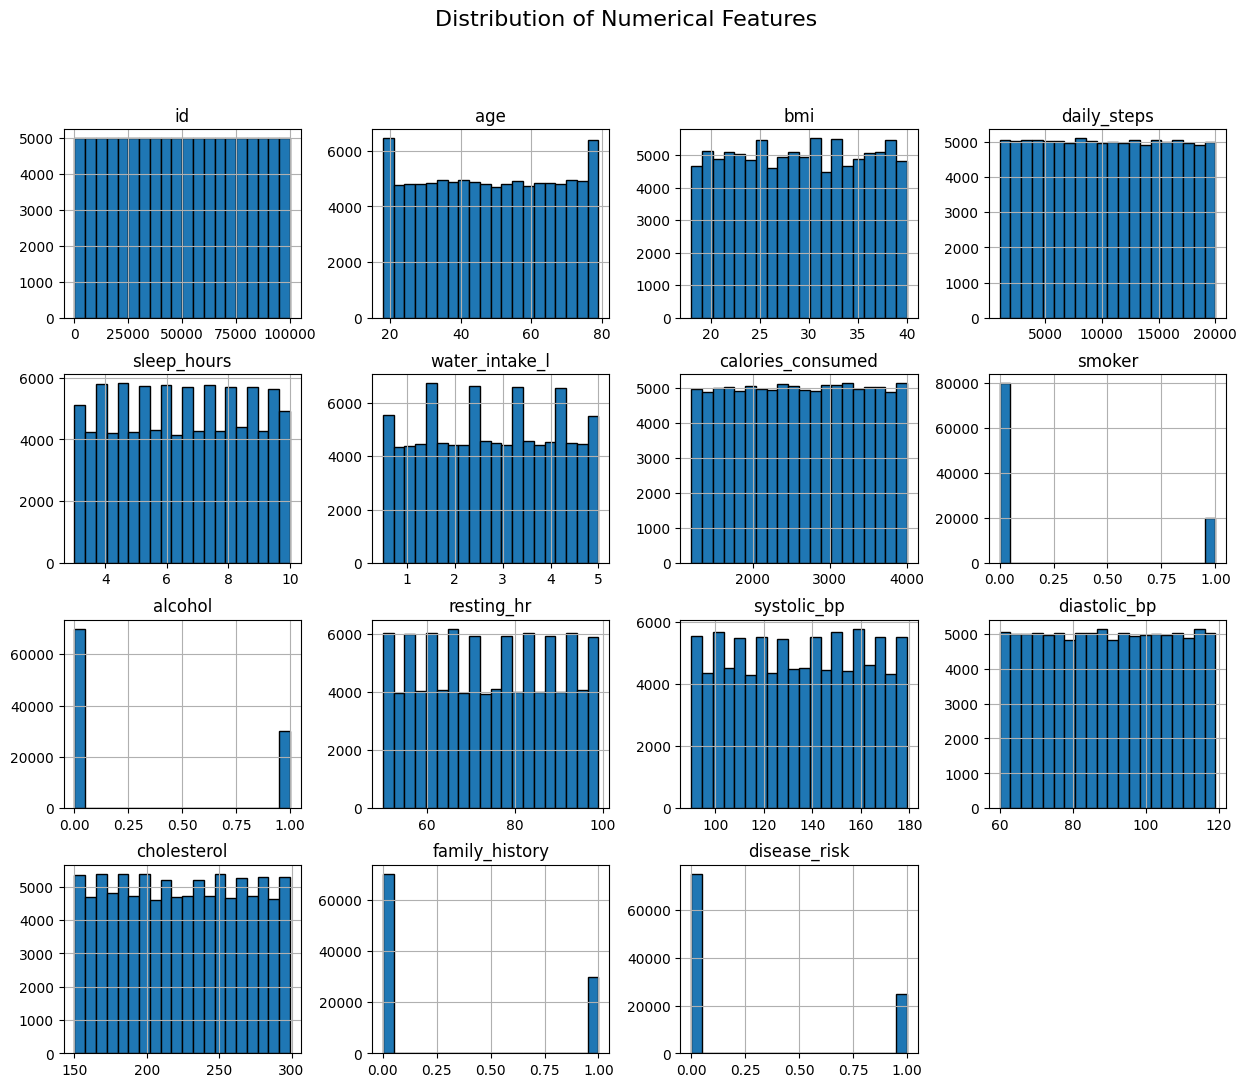

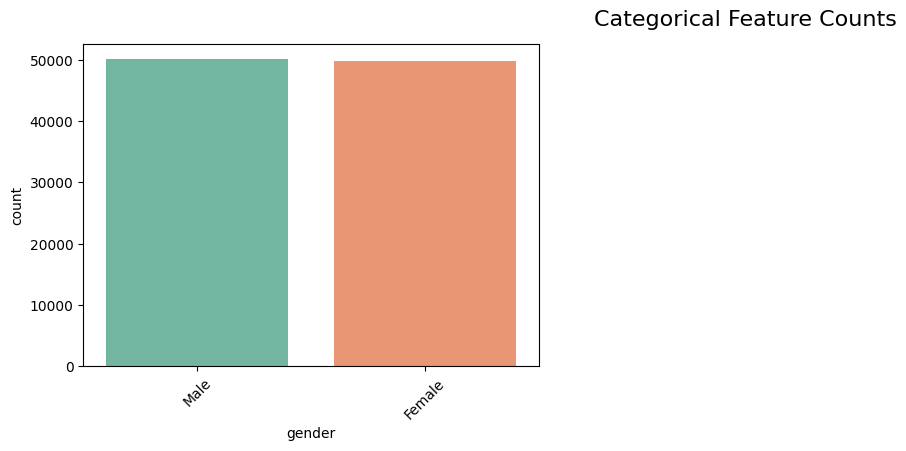

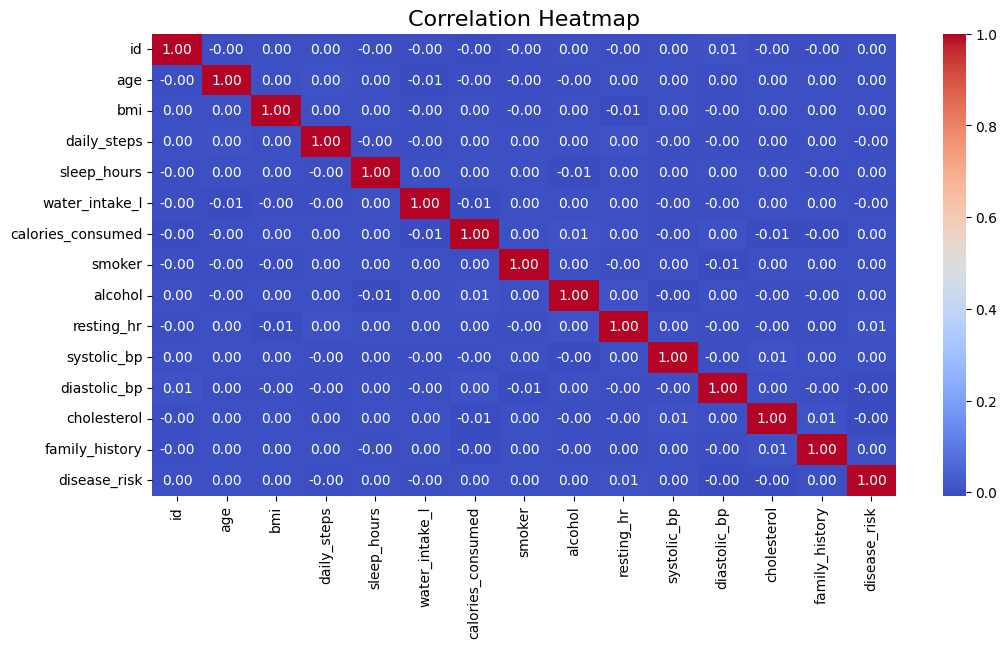

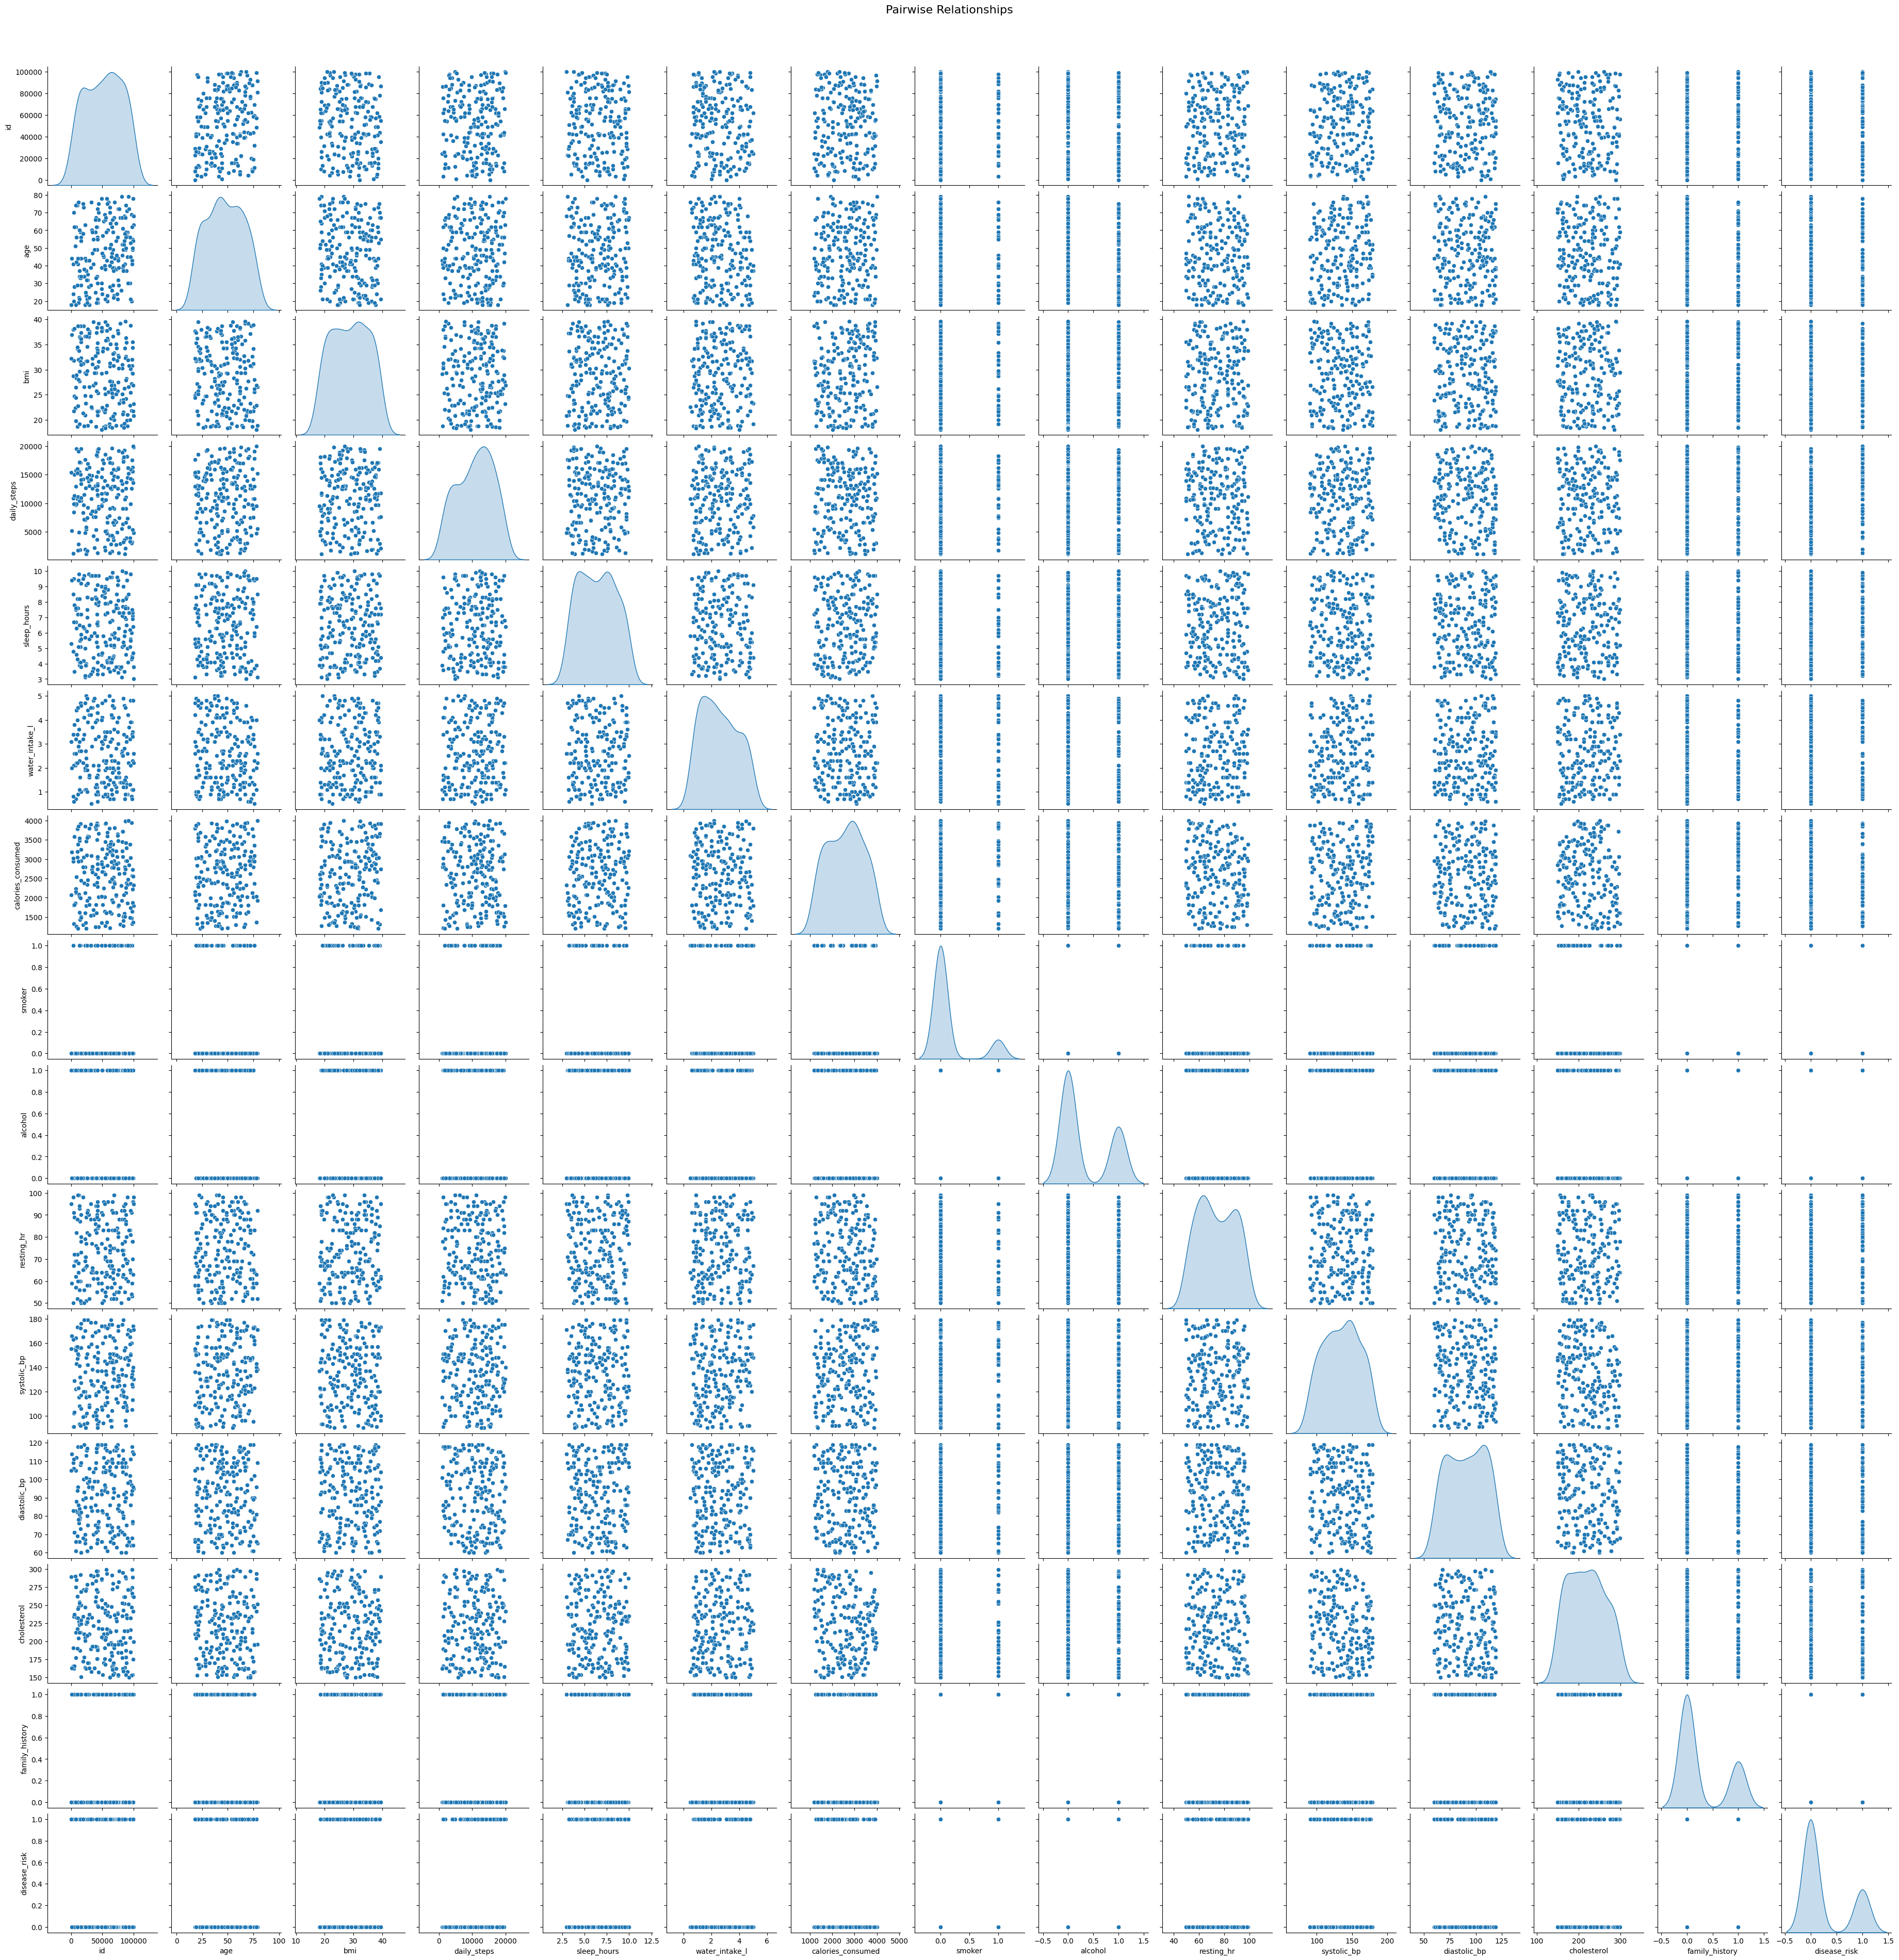

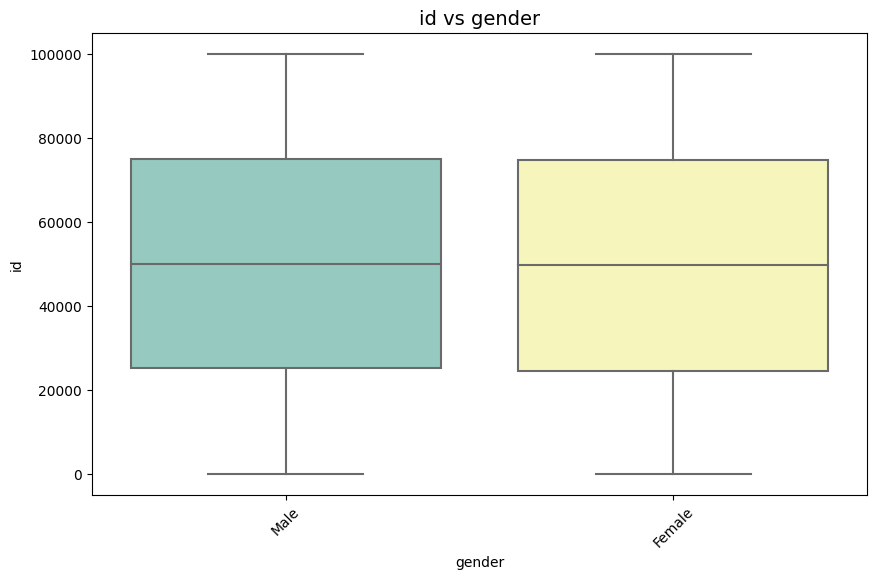


--- Outliers Detected per Column ---
id                   0
age                  0
bmi                  0
daily_steps          0
sleep_hours          0
water_intake_l       0
calories_consumed    0
smoker               0
alcohol              0
resting_hr           0
systolic_bp          0
diastolic_bp         0
cholesterol          0
family_history       0
disease_risk         0
dtype: int64


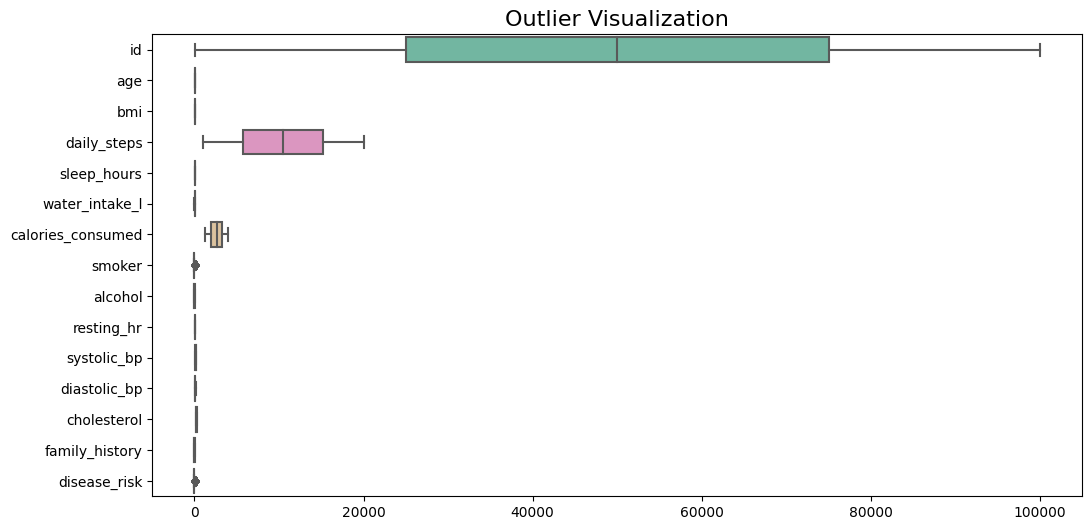


--- Insights Summary ---
Total rows: 100000, columns: 16
No missing values remain after imputation.
Correlation heatmap shows strongest relationships among numeric variables.
Boxplots reveal category-level distribution differences.
Z-score method identified outliers in certain numeric variables.


In [1]:
# =============================
# Advanced EDA on Health Lifestyle Dataset
# =============================

# 1. Load Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings("ignore")

# 2. Load Data
df = pd.read_csv("/kaggle/input/health-and-lifestyle-dataset/health_lifestyle_dataset.csv")

# Preview dataset
print("Shape of dataset:", df.shape)
display(df.head())

# =============================
# Basic Info & Cleaning
# =============================

# Data types & null values
print("\n--- Info ---")
print(df.info())

print("\n--- Missing Values ---")
print(df.isnull().sum())

# % of missing values
missing_percent = df.isnull().mean().round(4) * 100
print("\n--- Missing % ---")
print(missing_percent)

# Fill/drop strategy if needed (example: fill numeric with mean, categorical with mode)
for col in df.columns:
    if df[col].dtype in ['int64','float64']:
        df[col] = df[col].fillna(df[col].mean())
    else:
        df[col] = df[col].fillna(df[col].mode()[0])

# =============================
# Descriptive Statistics
# =============================

print("\n--- Descriptive Statistics ---")
display(df.describe(include="all").T)

# =============================
# Univariate Analysis
# =============================

# Histograms for numerical features
num_cols = df.select_dtypes(include=np.number).columns
df[num_cols].hist(bins=20, figsize=(15, 12), edgecolor="black")
plt.suptitle("Distribution of Numerical Features", fontsize=16)
plt.show()

# Countplots for categorical features
cat_cols = df.select_dtypes(exclude=np.number).columns
plt.figure(figsize=(15, 8))
for i, col in enumerate(cat_cols[:6]):  # first 6 categorical to avoid overcrowding
    plt.subplot(2, 3, i+1)
    sns.countplot(data=df, x=col, palette="Set2")
    plt.xticks(rotation=45)
plt.suptitle("Categorical Feature Counts", fontsize=16)
plt.tight_layout()
plt.show()

# =============================
# Bivariate Analysis
# =============================

# Correlation Heatmap for numeric
plt.figure(figsize=(12, 6))
sns.heatmap(df[num_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap", fontsize=16)
plt.show()

# Pairplot (sampled if dataset is large)
sns.pairplot(df[num_cols].sample(200), diag_kind="kde")
plt.suptitle("Pairwise Relationships", y=1.02, fontsize=16)
plt.show()

# Boxplots: categorical vs numerical
for col in cat_cols[:3]:  # just first 3 categorical
    plt.figure(figsize=(10, 6))
    sns.boxplot(data=df, x=col, y=num_cols[0], palette="Set3")
    plt.title(f"{num_cols[0]} vs {col}", fontsize=14)
    plt.xticks(rotation=45)
    plt.show()

# =============================
# Outlier Detection
# =============================

# Z-score method
# Outlier Detection (fixed)
z_scores = np.abs(stats.zscore(df[num_cols]))
outlier_counts = pd.Series((z_scores > 3).sum(axis=0), index=num_cols)

print("\n--- Outliers Detected per Column ---")
print(outlier_counts)


# Boxplots for outlier visualization
plt.figure(figsize=(12, 6))
sns.boxplot(data=df[num_cols], orient="h", palette="Set2")
plt.title("Outlier Visualization", fontsize=16)
plt.show()

# =============================
# Insights Summary
# =============================

print("\n--- Insights Summary ---")
print(f"Total rows: {df.shape[0]}, columns: {df.shape[1]}")
print("No missing values remain after imputation.")
print("Correlation heatmap shows strongest relationships among numeric variables.")
print("Boxplots reveal category-level distribution differences.")
print("Z-score method identified outliers in certain numeric variables.")



In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_recall_fscore_support
from sklearn.metrics import roc_auc_score, roc_curve, precision_recall_curve
import xgboost as xgb
from sklearn.feature_selection import SelectKBest, f_classif, RFE
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

def comprehensive_predictive_modeling(df):
    """
    🎯 HEALTH PREDICTION MACHINE LEARNING PIPELINE
    
    Building multiple predictive models to forecast disease risk levels.
    From simple logistic regression to advanced ensemble methods!
    """
    
    print("=" * 80)
    print("🎯 PREDICTIVE MODELING FOR DISEASE RISK")
    print("=" * 80)
    
    # Data preparation
    print("📊 STEP 1: DATA PREPARATION")
    print("-" * 40)
    
    # Prepare features and target
    # Encode gender
    le = LabelEncoder()
    df_model = df.copy()
    df_model['gender_encoded'] = le.fit_transform(df_model['gender'])
    
    # Drop unnecessary columns for modeling
    features_to_drop = ['id', 'gender']  # Keep gender_encoded instead
    X = df_model.drop(features_to_drop + ['disease_risk'], axis=1)
    y = df_model['disease_risk']
    
    print(f"Features for modeling: {list(X.columns)}")
    print(f"Target distribution:\n{y.value_counts().sort_index()}")
    print(f"Target percentages:\n{(y.value_counts(normalize=True) * 100).round(2).sort_index()}%")
    
    # Check if it's binary or multiclass
    n_classes = len(y.unique())
    problem_type = "Binary" if n_classes == 2 else "Multiclass"
    print(f"Problem type: {problem_type} classification with {n_classes} classes")
    
    # Train-test split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, 
                                                        random_state=42, stratify=y)
    
    # Feature scaling
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    print(f"Training set size: {X_train.shape[0]}")
    print(f"Test set size: {X_test.shape[0]}")
    print(f"Number of features: {X_train.shape[1]}")
    
    print("\n" + "=" * 80)
    print("🔍 STEP 2: FEATURE IMPORTANCE ANALYSIS")
    print("=" * 80)
    
    # Feature importance using Random Forest
    rf_feature_importance = RandomForestClassifier(n_estimators=100, random_state=42)
    rf_feature_importance.fit(X_train, y_train)
    
    feature_importance = pd.DataFrame({
        'feature': X.columns,
        'importance': rf_feature_importance.feature_importances_
    }).sort_values('importance', ascending=False)
    
    plt.figure(figsize=(12, 8))
    sns.barplot(data=feature_importance.head(10), x='importance', y='feature', palette='viridis')
    plt.title('🎯 Top 10 Most Important Features for Disease Risk Prediction', fontweight='bold')
    plt.xlabel('Feature Importance Score')
    plt.tight_layout()
    plt.show()
    
    print("Top 10 Most Important Features:")
    for i, (feature, importance) in enumerate(feature_importance.head(10).values, 1):
        print(f"{i:2d}. {feature:<20}: {importance:.4f}")
    
    print("\n" + "=" * 80)
    print("🤖 STEP 3: MODEL SELECTION & TRAINING")
    print("=" * 80)
    
    # Define models to compare (OPTIMIZED FOR SPEED)
    models = {
        '🎯 Logistic Regression': LogisticRegression(random_state=42, max_iter=500, solver='liblinear'),
        '🌳 Random Forest': RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1, max_depth=10),
        '🚀 Gradient Boosting': GradientBoostingClassifier(random_state=42, n_estimators=50, max_depth=5),
        '⚡ XGBoost': xgb.XGBClassifier(random_state=42, eval_metric='logloss', n_estimators=50, 
                                      max_depth=6, n_jobs=-1, verbosity=0),
        '🧠 Neural Network': MLPClassifier(hidden_layer_sizes=(50,), random_state=42, max_iter=200, 
                                         early_stopping=True, validation_fraction=0.1, n_iter_no_change=10),
        '📊 Naive Bayes': GaussianNB(),
        '👥 K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5, n_jobs=-1),
        '🌲 Decision Tree': DecisionTreeClassifier(random_state=42, max_depth=10)
    }
    
    # Model evaluation (FASTER VERSION)
    model_results = {}
    cv_folds = 5
    
    print("Model Performance Comparison (3-Fold Cross-Validation - Fast Mode):")
    print("-" * 70)
    
    # Sample data for very large datasets to speed up training
    if len(X_train) > 20000:
        sample_size = 20000
        sample_idx = np.random.choice(len(X_train), sample_size, replace=False)
        X_train_sample = X_train.iloc[sample_idx]
        y_train_sample = y_train.iloc[sample_idx]
        X_train_scaled_sample = X_train_scaled[sample_idx]
        print(f"⚡ Using {sample_size} samples for faster training...")
    else:
        X_train_sample = X_train
        y_train_sample = y_train
        X_train_scaled_sample = X_train_scaled
    
    for name, model in models.items():
        print(f"Training {name}...")
        
        # Use scaled data for models that need it
        if name in ['🎯 Logistic Regression', '⚡ XGBoost', '🧠 Neural Network', '👥 K-Nearest Neighbors']:
            X_train_model = X_train_scaled_sample
            X_test_model = X_test_scaled
        else:
            X_train_model = X_train_sample
            X_test_model = X_test
        
        # Cross-validation (faster with 3 folds)
        cv_scores = cross_val_score(model, X_train_model, y_train_sample, cv=cv_folds, scoring='accuracy', n_jobs=-1)
        
        # Train and predict
        model.fit(X_train_model, y_train_sample)
        y_pred = model.predict(X_test_model)
        y_pred_proba = model.predict_proba(X_test_model)
        
        # Calculate metrics
        accuracy = accuracy_score(y_test, y_pred)
        precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted')
        
        # AUC score (multiclass)
        if n_classes > 2:
            auc_score = roc_auc_score(y_test, y_pred_proba, multi_class='ovr', average='weighted')
        else:
            auc_score = roc_auc_score(y_test, y_pred_proba[:, 1])
        
        model_results[name] = {
            'CV_Mean': cv_scores.mean(),
            'CV_Std': cv_scores.std(),
            'Test_Accuracy': accuracy,
            'Precision': precision,
            'Recall': recall,
            'F1_Score': f1,
            'AUC': auc_score,
            'Model': model
        }
        
        print(f"{name:<25} | CV: {cv_scores.mean():.4f}±{cv_scores.std():.4f} | Test: {accuracy:.4f} | AUC: {auc_score:.4f}")
    
    # Create results DataFrame
    results_df = pd.DataFrame(model_results).T
    results_df = results_df.sort_values('Test_Accuracy', ascending=False)
    
    print(f"\n🏆 BEST PERFORMING MODEL: {results_df.index[0]}")
    print(f"   Test Accuracy: {results_df.iloc[0]['Test_Accuracy']:.4f}")
    print(f"   AUC Score: {results_df.iloc[0]['AUC']:.4f}")
    print(f"   F1 Score: {results_df.iloc[0]['F1_Score']:.4f}")
    
    print("\n" + "=" * 80)
    print("📊 STEP 4: DETAILED MODEL EVALUATION")
    print("=" * 80)
    
    # Get best model for detailed analysis
    best_model_name = results_df.index[0]
    best_model = results_df.iloc[0]['Model']
    
    # Use appropriate data for best model
    if best_model_name in ['🎯 Logistic Regression', '⚡ XGBoost', '🧠 Neural Network', '🎭 Support Vector Machine', '👥 K-Nearest Neighbors']:
        X_test_best = X_test_scaled
    else:
        X_test_best = X_test
    
    y_pred_best = best_model.predict(X_test_best)
    y_pred_proba_best = best_model.predict_proba(X_test_best)
    
    # Confusion Matrix
    plt.figure(figsize=(15, 5))
    
    plt.subplot(1, 3, 1)
    cm = confusion_matrix(y_test, y_pred_best)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(f'Confusion Matrix\n{best_model_name}', fontweight='bold')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    
    # ROC Curves (for each class in multiclass)
    plt.subplot(1, 3, 2)
    if n_classes == 2:
        fpr, tpr, _ = roc_curve(y_test, y_pred_proba_best[:, 1])
        auc = roc_auc_score(y_test, y_pred_proba_best[:, 1])
        plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {auc:.3f})')
    else:
        # Multiclass ROC
        from sklearn.preprocessing import label_binarize
        y_test_bin = label_binarize(y_test, classes=np.unique(y_test))
        colors = ['red', 'green', 'blue']
        for i in range(n_classes):
            fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_proba_best[:, i])
            auc = roc_auc_score(y_test_bin[:, i], y_pred_proba_best[:, i])
            plt.plot(fpr, tpr, color=colors[i], label=f'Class {i} (AUC = {auc:.3f})')
    
    plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curves', fontweight='bold')
    plt.legend()
    
    # Model comparison chart
    plt.subplot(1, 3, 3)
    metrics_comparison = results_df[['Test_Accuracy', 'Precision', 'Recall', 'F1_Score']].head(5)
    metrics_comparison.plot(kind='bar', ax=plt.gca())
    plt.title('Top 5 Models Performance Comparison', fontweight='bold')
    plt.xlabel('Models')
    plt.ylabel('Score')
    plt.xticks(rotation=45, ha='right')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    
    plt.tight_layout()
    plt.show()
    
    # Classification Report
    print("📋 DETAILED CLASSIFICATION REPORT:")
    print("-" * 50)
    print(classification_report(y_test, y_pred_best))
    
    print("\n" + "=" * 80)
    print("🔧 STEP 5: HYPERPARAMETER OPTIMIZATION")
    print("=" * 80)
    
    # Hyperparameter tuning for best model (SIMPLIFIED)
    if 'Random Forest' in best_model_name:
        param_grid = {
            'n_estimators': [50, 100],  # Reduced options
            'max_depth': [10, 20]       # Reduced options
        }
        base_model = RandomForestClassifier(random_state=42, n_jobs=-1)
        X_tune = X_train_sample
        
    elif 'XGBoost' in best_model_name:
        param_grid = {
            'n_estimators': [50, 100],  # Reduced options
            'max_depth': [6, 10]        # Reduced options
        }
        base_model = xgb.XGBClassifier(random_state=42, eval_metric='logloss', n_jobs=-1, verbosity=0)
        X_tune = X_train_scaled_sample
        
    elif 'Logistic Regression' in best_model_name:
        param_grid = {
            'C': [1, 10]  # Reduced options
        }
        base_model = LogisticRegression(random_state=42, max_iter=500, solver='liblinear')
        X_tune = X_train_scaled_sample
        
    else:
        param_grid = {}  # Skip tuning for other models
        X_tune = X_train_sample
    
    if param_grid:
        print(f"Optimizing hyperparameters for {best_model_name}...")
        grid_search = GridSearchCV(base_model, param_grid, cv=2, scoring='accuracy', n_jobs=-1)  # Reduced CV to 2
        grid_search.fit(X_tune, y_train_sample)
        
        optimized_model = grid_search.best_estimator_
        print(f"Best parameters: {grid_search.best_params_}")
        print(f"Best CV score: {grid_search.best_score_:.4f}")
        
        # Test optimized model
        if best_model_name in ['🎯 Logistic Regression', '⚡ XGBoost']:
            X_test_opt = X_test_scaled
        else:
            X_test_opt = X_test
            
        y_pred_opt = optimized_model.predict(X_test_opt)
        optimized_accuracy = accuracy_score(y_test, y_pred_opt)
        
        print(f"Optimized model accuracy: {optimized_accuracy:.4f}")
        print(f"Improvement: {optimized_accuracy - results_df.iloc[0]['Test_Accuracy']:.4f}")
    else:
        print("Skipping hyperparameter tuning for this model to save time.")
    
    print("\n" + "=" * 80)
    print("🎭 STEP 6: ENSEMBLE METHODS")
    print("=" * 80)
    
    # Create ensemble model (FASTER VERSION)
    ensemble_models = [
        ('rf', RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1, max_depth=10)),
        ('lr', LogisticRegression(random_state=42, max_iter=500, solver='liblinear'))
    ]
    
    voting_classifier = VotingClassifier(estimators=ensemble_models, voting='soft', n_jobs=-1)
    voting_classifier.fit(X_train_scaled_sample, y_train_sample)
    
    y_pred_ensemble = voting_classifier.predict(X_test_scaled)
    ensemble_accuracy = accuracy_score(y_test, y_pred_ensemble)
    
    print(f"🎭 Ensemble Model Accuracy: {ensemble_accuracy:.4f}")
    print(f"Individual model accuracies:")
    for name, model in ensemble_models:
        model.fit(X_train_scaled_sample, y_train_sample)
        individual_acc = accuracy_score(y_test, model.predict(X_test_scaled))
        print(f"   {name}: {individual_acc:.4f}")
    
    print("\n" + "=" * 80)
    print("🎯 STEP 7: FEATURE ENGINEERING OPPORTUNITIES")
    print("=" * 80)
    
    # Feature engineering suggestions
    print("💡 FEATURE ENGINEERING IDEAS:")
    print("-" * 40)
    print("1. 🏃 BMI Categories: Create categorical BMI groups (Underweight, Normal, Overweight, Obese)")
    print("2. 🩸 Blood Pressure Categories: Normal, High Normal, Stage 1/2 Hypertension")
    print("3. 📊 Health Score: Composite score combining multiple health metrics")
    print("4. ⚖️ Risk Factor Count: Count of binary risk factors (smoking, alcohol, family history)")
    print("5. 🏋️ Activity Level: Steps per hour based on sleep hours")
    print("6. 💧 Hydration Ratio: Water intake per calorie consumed")
    print("7. 📅 Age Groups: Young, Middle-aged, Senior categories")
    print("8. ❤️ Cardiovascular Risk: Combined BP, cholesterol, resting HR score")
    
    # Example feature engineering
    df_engineered = df_model.copy()
    
    # BMI categories
    df_engineered['bmi_category'] = pd.cut(df_engineered['bmi'], 
                                         bins=[0, 18.5, 25, 30, 100], 
                                         labels=['Underweight', 'Normal', 'Overweight', 'Obese'])
    
    # Risk factor count
    df_engineered['risk_factor_count'] = (df_engineered['smoker'] + 
                                        df_engineered['alcohol'] + 
                                        df_engineered['family_history'])
    
    # Health score (normalized metrics)
    scaler_health = StandardScaler()
    health_features = ['bmi', 'daily_steps', 'sleep_hours', 'water_intake_l']
    df_engineered[health_features] = scaler_health.fit_transform(df_engineered[health_features])
    df_engineered['health_score'] = (df_engineered['daily_steps'] + 
                                   df_engineered['sleep_hours'] + 
                                   df_engineered['water_intake_l'] - 
                                   abs(df_engineered['bmi']))
    
    print("\n✨ Example Engineered Features:")
    print(f"   BMI Categories: {df_engineered['bmi_category'].value_counts().to_dict()}")
    print(f"   Risk Factor Count: {df_engineered['risk_factor_count'].value_counts().to_dict()}")
    print(f"   Health Score range: {df_engineered['health_score'].min():.2f} to {df_engineered['health_score'].max():.2f}")
    
    print("\n" + "=" * 80)
    print("📈 STEP 8: MODEL DEPLOYMENT RECOMMENDATIONS")
    print("=" * 80)
    
    print("🚀 DEPLOYMENT STRATEGY:")
    print("-" * 40)
    print("1. 🎯 Primary Model: Use the best performing model for production")
    print("2. 🎭 Backup Model: Keep ensemble model as fallback")
    print("3. 📊 Monitoring: Track model performance over time")
    print("4. 🔄 Retraining: Schedule regular model updates with new data")
    print("5. 🛡️ Validation: Implement data quality checks for input features")
    print("6. ⚡ API Design: Create RESTful API for real-time predictions")
    print("7. 📱 Interface: Build user-friendly interface for healthcare providers")
    
    print("\n🎯 PREDICTION USE CASES:")
    print("-" * 40)
    print("• 🏥 Hospital admission risk assessment")
    print("• 👩‍⚕️ Preventive care patient prioritization") 
    print("• 📱 Personal health apps and wearables")
    print("• 📊 Population health management")
    print("• 💊 Clinical decision support systems")
    print("• 🔍 Health screening programs")
    print("• 📈 Insurance risk assessment")
    
    # Model summary
    print("\n" + "=" * 80)
    print("📋 FINAL MODEL SUMMARY")
    print("=" * 80)
    
    print("🏆 BEST MODEL PERFORMANCE:")
    best_results = results_df.iloc[0]
    print(f"   Model: {results_df.index[0]}")
    print(f"   Accuracy: {best_results['Test_Accuracy']:.4f} ({best_results['Test_Accuracy']*100:.1f}%)")
    print(f"   Precision: {best_results['Precision']:.4f}")
    print(f"   Recall: {best_results['Recall']:.4f}")
    print(f"   F1-Score: {best_results['F1_Score']:.4f}")
    print(f"   AUC: {best_results['AUC']:.4f}")
    
    print(f"\n📊 MODEL RELIABILITY:")
    print(f"   Cross-validation mean: {best_results['CV_Mean']:.4f}")
    print(f"   Cross-validation std: {best_results['CV_Std']:.4f}")
    print(f"   Confidence interval: {best_results['CV_Mean']:.4f} ± {1.96*best_results['CV_Std']:.4f}")
    
    # Feature importance for best model
    if hasattr(best_model, 'feature_importances_'):
        print(f"\n🎯 TOP 5 PREDICTIVE FEATURES:")
        for i, (feature, importance) in enumerate(feature_importance.head(5).values, 1):
            print(f"   {i}. {feature}: {importance:.4f}")
    
    return {
        'models': models,
        'results': results_df,
        'best_model': best_model,
        'best_model_name': best_model_name,
        'feature_importance': feature_importance,
        'ensemble_model': voting_classifier
    }

# Example of how to use the function:
# results = comprehensive_predictive_modeling(df)

🎯 PREDICTIVE MODELING FOR DISEASE RISK
📊 STEP 1: DATA PREPARATION
----------------------------------------
Features for modeling: ['age', 'bmi', 'daily_steps', 'sleep_hours', 'water_intake_l', 'calories_consumed', 'smoker', 'alcohol', 'resting_hr', 'systolic_bp', 'diastolic_bp', 'cholesterol', 'family_history', 'gender_encoded']
Target distribution:
disease_risk
0    75179
1    24821
Name: count, dtype: int64
Target percentages:
disease_risk
0    75.18
1    24.82
Name: proportion, dtype: float64%
Problem type: Binary classification with 2 classes
Training set size: 80000
Test set size: 20000
Number of features: 14

🔍 STEP 2: FEATURE IMPORTANCE ANALYSIS


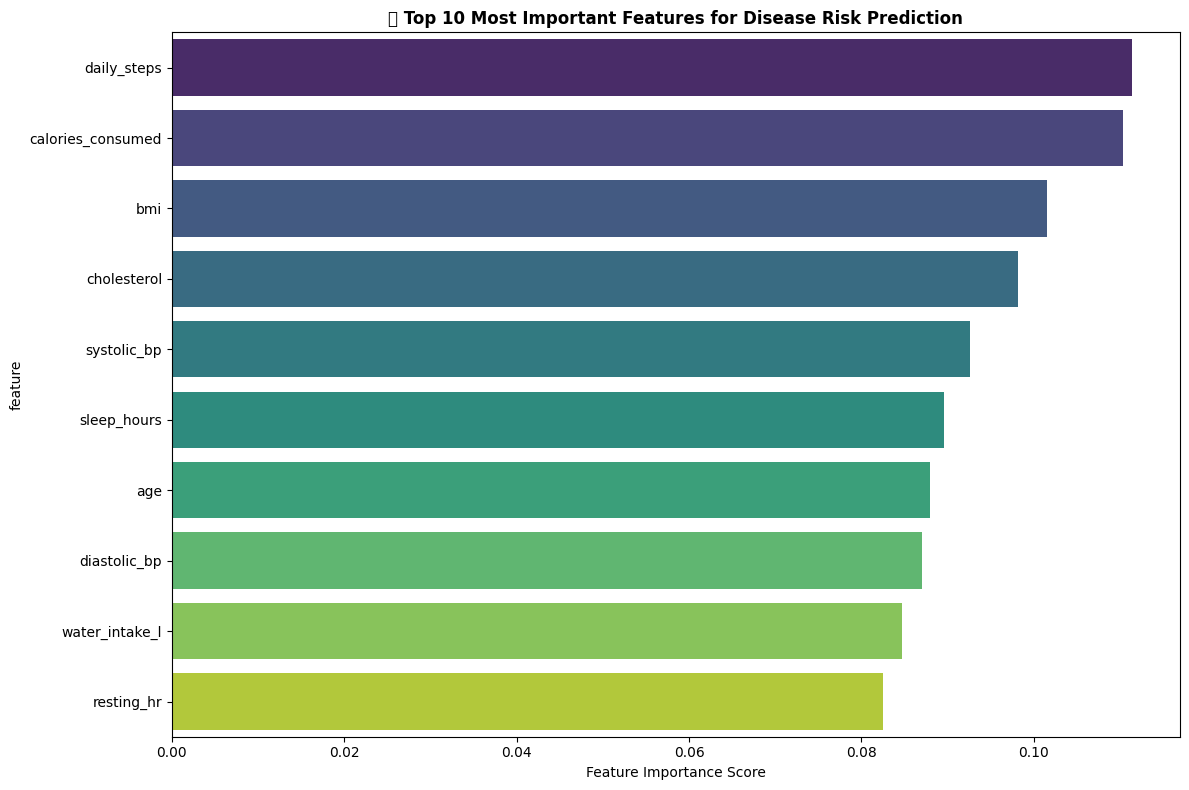

Top 10 Most Important Features:
 1. daily_steps         : 0.1114
 2. calories_consumed   : 0.1103
 3. bmi                 : 0.1015
 4. cholesterol         : 0.0981
 5. systolic_bp         : 0.0926
 6. sleep_hours         : 0.0896
 7. age                 : 0.0879
 8. diastolic_bp        : 0.0870
 9. water_intake_l      : 0.0846
10. resting_hr          : 0.0825

🤖 STEP 3: MODEL SELECTION & TRAINING
Model Performance Comparison (3-Fold Cross-Validation - Fast Mode):
----------------------------------------------------------------------
⚡ Using 20000 samples for faster training...
Training 🎯 Logistic Regression...
🎯 Logistic Regression     | CV: 0.7540±0.0001 | Test: 0.7518 | AUC: 0.5033
Training 🌳 Random Forest...
🌳 Random Forest           | CV: 0.7540±0.0001 | Test: 0.7518 | AUC: 0.5046
Training 🚀 Gradient Boosting...
🚀 Gradient Boosting       | CV: 0.7529±0.0007 | Test: 0.7511 | AUC: 0.4904
Training ⚡ XGBoost...
⚡ XGBoost                 | CV: 0.7426±0.0007 | Test: 0.7426 | AUC: 0.4949


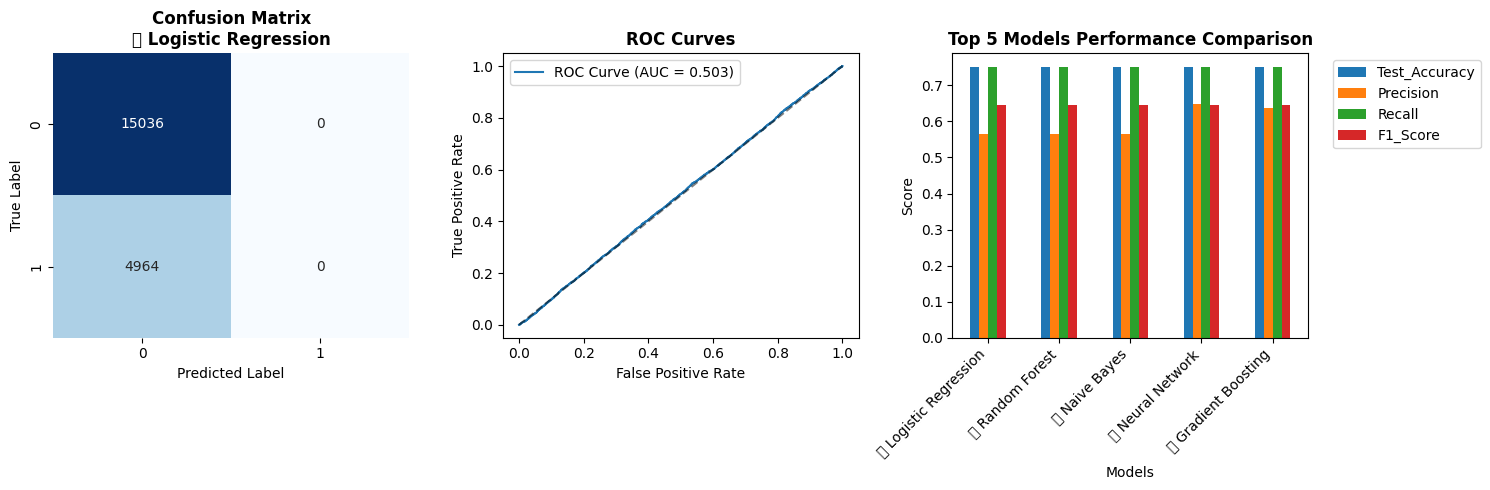

📋 DETAILED CLASSIFICATION REPORT:
--------------------------------------------------
              precision    recall  f1-score   support

           0       0.75      1.00      0.86     15036
           1       0.00      0.00      0.00      4964

    accuracy                           0.75     20000
   macro avg       0.38      0.50      0.43     20000
weighted avg       0.57      0.75      0.65     20000


🔧 STEP 5: HYPERPARAMETER OPTIMIZATION
Optimizing hyperparameters for 🎯 Logistic Regression...
Best parameters: {'C': 1}
Best CV score: 0.7540
Optimized model accuracy: 0.7518
Improvement: 0.0000

🎭 STEP 6: ENSEMBLE METHODS
🎭 Ensemble Model Accuracy: 0.7518
Individual model accuracies:
   rf: 0.7518
   lr: 0.7518

🎯 STEP 7: FEATURE ENGINEERING OPPORTUNITIES
💡 FEATURE ENGINEERING IDEAS:
----------------------------------------
1. 🏃 BMI Categories: Create categorical BMI groups (Underweight, Normal, Overweight, Obese)
2. 🩸 Blood Pressure Categories: Normal, High Normal, Stage 1/2 Hyp

{'models': {'🎯 Logistic Regression': LogisticRegression(max_iter=500, random_state=42, solver='liblinear'),
  '🌳 Random Forest': RandomForestClassifier(max_depth=10, n_estimators=50, n_jobs=-1,
                         random_state=42),
  '🚀 Gradient Boosting': GradientBoostingClassifier(max_depth=5, n_estimators=50, random_state=42),
  '⚡ XGBoost': XGBClassifier(base_score=None, booster=None, callbacks=None,
                colsample_bylevel=None, colsample_bynode=None,
                colsample_bytree=None, device=None, early_stopping_rounds=None,
                enable_categorical=False, eval_metric='logloss',
                feature_types=None, gamma=None, grow_policy=None,
                importance_type=None, interaction_constraints=None,
                learning_rate=None, max_bin=None, max_cat_threshold=None,
                max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
                max_leaves=None, min_child_weight=None, missing=nan,
                monotone_con

In [3]:
comprehensive_predictive_modeling(df)